# Análisis exploratorio: Online Retail II

Exploración del dataset de ventas retail online (transacciones, productos, clientes y países).

**Contenido:**
- Carga y primera inspección
- Calidad de datos (nulos, duplicados, tipos)
- Estadísticas descriptivas
- Visualizaciones (distribuciones, series temporales, categorías)
- Conclusiones del EDA

In [1]:
import warnings
warnings.filterwarnings('ignore')

#Programas hechos por mí
from src.extraccion import load_from_pickle
from src.anejo import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)
plt.style.use('fivethirtyeight') 
sns.set_palette('husl')

## 1. Carga de datos

In [2]:
df=load_from_pickle()

## 2. Inspección y calidad de los datos

In [3]:
informacion(df)

Contiene 1,067,371 instancias y 8 atributos
Por año:
2009 : 45,228 instancias.
2010 : 522,714 instancias.
2011 : 499,429 instancias.

             Tipo de variable  NA 2009  NA 2009 %  NA 2010  NA 2010 %  NA 2011  \
Invoice               object        0        0.0        0        0.0        0   
StockCode             object        0        0.0        0        0.0        0   
Description           object      228        0.5     2825        0.5     1329   
Quantity               int64        0        0.0        0        0.0        0   
InvoiceDate   datetime64[us]        0        0.0        0        0.0        0   
Price                float64        0        0.0        0        0.0        0   
Customer ID          float64    13468       29.8   110090       21.1   119449   
Country                  str        0        0.0        0        0.0        0   

             NA 2011 %  
Invoice            0.0  
StockCode          0.0  
Description        0.3  
Quantity           0.0  
InvoiceDat

- Se podría eliminar instancias con null values de `Decription` 
- No es recomendable eliminar instancias con null values de `Customer ID`.

Viendo si los valores nulos de `Description` están incluidos en las instancias que coinciden con los valores nulos de `Customer ID`


In [4]:
na_desc=df[(df['Description'].isnull()) & (df['Customer ID'].isnull())].shape[0]
print('Null values de Description que coinciden con null values de Customer ID:',na_desc)
print('¿Es igual al total de null values de Description?:',na_desc==228+2825+1329) 

Null values de Description que coinciden con null values de Customer ID: 4382
¿Es igual al total de null values de Description?: True


Se comprueba que todos los valores nulos de `Description` corresponden a valores nulos en `CustomerID`.

### Duplicados exactos

In [5]:
duplicados = df.duplicated().sum()
print(f"\nFilas duplicadas: {duplicados:,} ({duplicados/len(df)*100:.2f}%)")


Filas duplicadas: 34,335 (3.22%)


#### Eliminando instancias duplicadas

In [6]:
df=df.drop_duplicates()

### Valores negativos y anomalias

In [7]:
# Chequeo de valores negativos y anomalías
print("Valores negativos:")
print(f"  Quantity < 0: {(df['Quantity'] < 0).sum():,}")
print(f"  Price < 0: {(df['Price'] < 0).sum():,}")

# Filas con Customer ID nulo
print(f"\nFilas sin Customer ID: {df['Customer ID'].isnull().sum():,}")

# Facturas que empiezan con 'C' (devoluciones)
devoluciones = df[df['Invoice'].str.startswith('C', na=False)]
print(f"Filas de devoluciones (Invoice empieza con 'C'): {len(devoluciones):,}")

Valores negativos:
  Quantity < 0: 22,496
  Price < 0: 5

Filas sin Customer ID: 235,151
Filas de devoluciones (Invoice empieza con 'C'): 19,104


#### Viendo si los ticket de compra ya estaban eliminados

In [8]:
#Extraigo los dígitos de Invoice de las facturas de devolución
compras_devueltas=devoluciones['Invoice'].str.extract('([0-9]+)')
print("¿Hay algún ticket de compra en las devoluciones?:", df.Invoice.isin(compras_devueltas[0]).any())

¿Hay algún ticket de compra en las devoluciones?: False


#### Eliminando las devoluciones, cantidades y precios negativos (este último son muy puntuales)

In [9]:
#df=df[~df['Invoice'].str.startswith('C', na=False)]
df=df[~df['Invoice'].isin(devoluciones['Invoice'].unique())]
df=df[df['Price']>=0]
df=df[df['Quantity']>0]

#### Country

In [10]:
df.Country.unique()

<StringArray>
[      'United Kingdom',               'France',                  'USA',
              'Belgium',            'Australia',                 'EIRE',
              'Germany',             'Portugal',              'Denmark',
          'Netherlands',               'Poland',      'Channel Islands',
                'Spain',               'Cyprus',               'Greece',
               'Norway',              'Austria',               'Sweden',
 'United Arab Emirates',              'Finland',                'Italy',
          'Switzerland',                'Japan',          'Unspecified',
              'Nigeria',                'Malta',              'Bahrain',
                  'RSA',              'Bermuda',            'Hong Kong',
            'Singapore',             'Thailand',               'Israel',
            'Lithuania',          'West Indies',              'Lebanon',
                'Korea',               'Brazil',               'Canada',
              'Iceland',         'Sau

- `Unspecified` corresponde a valor nulo.
- `European Community` es muy genérico.

In [11]:
df.query("Country == 'European Community' | Country == 'Unspecified'").Country.value_counts()

Country
Unspecified           748
European Community     60
Name: count, dtype: int64

#### Elimino las instancias de aquellos dos valores en Country con el fin de no contaminar el modelo y además, son una minoría.

In [12]:
df=df[~((df.Country=='European Community') | (df.Country=='Unspecified'))]

# 3. Estadísticas descriptivas

In [13]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.009726e+06,1009726,1.009726e+06,778917.000000
mean,1.133840e+01,2011-01-04 05:57:45.087914,4.064492e+00,15320.761962
min,1.000000e+00,2009-12-01 07:45:00,0.000000e+00,12346.000000
25%,1.000000e+00,2010-07-06 09:51:00,1.250000e+00,13971.000000
50%,4.000000e+00,2010-12-09 14:10:00,2.100000e+00,15248.000000
75%,1.200000e+01,2011-07-28 09:58:00,4.130000e+00,16794.000000
max,8.099500e+04,2011-12-09 12:50:00,2.511109e+04,18287.000000
std,1.315177e+02,NaN,5.038550e+01,1695.680211


# 4. Visualizaciones

In [14]:
# Calculando revenue
df['Revenue'] = df['Quantity'] * df['Price']

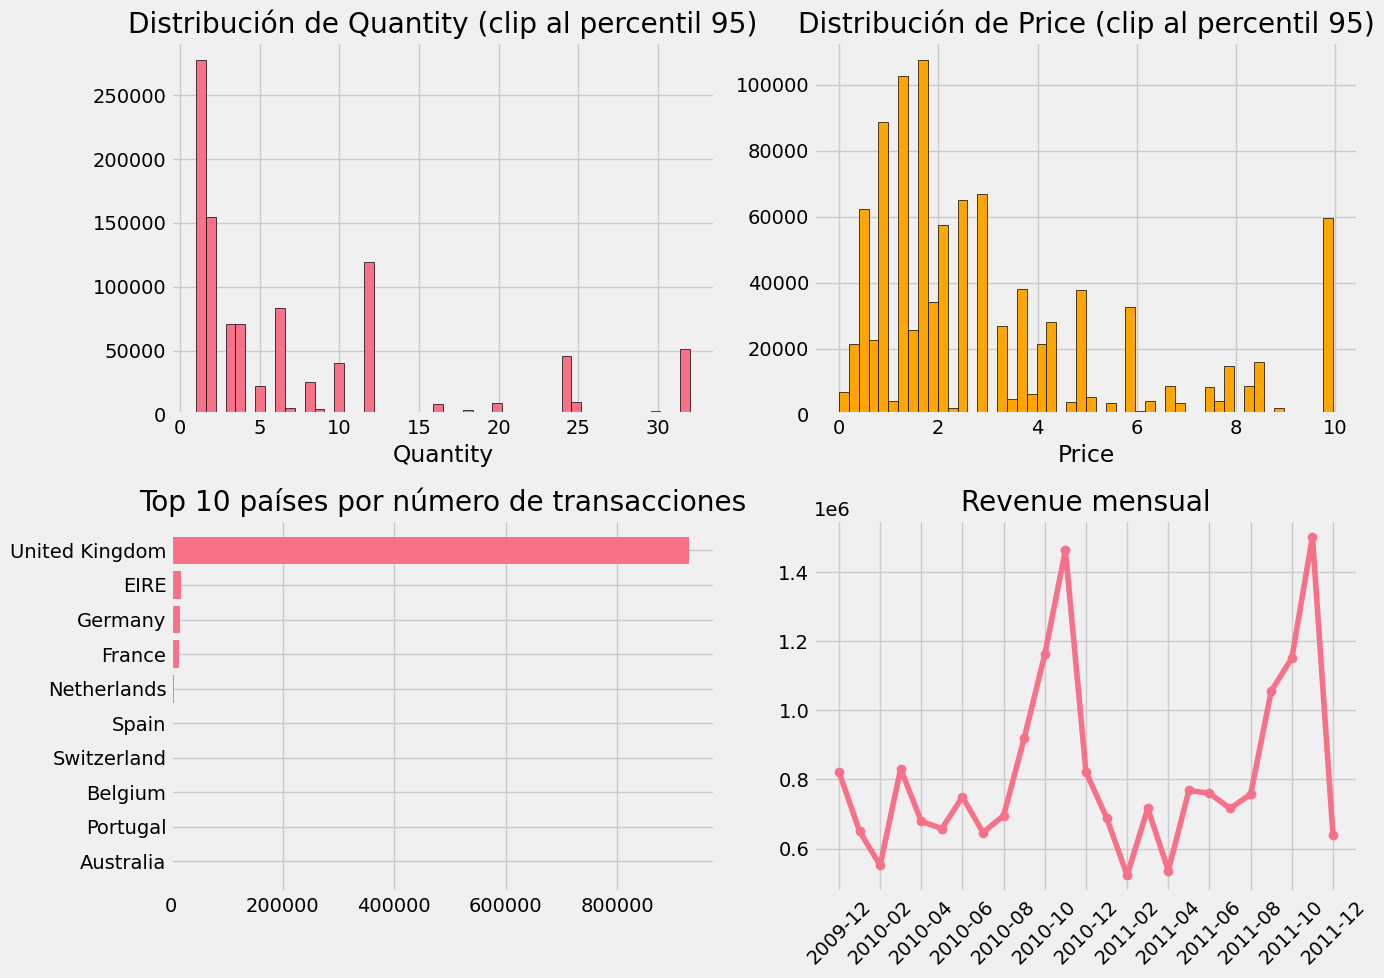

Revenue total: £20,464,033.04


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# 1. Distribución de Quantity (limitando a percentil 95 para ver mejor)
qty_95 = df['Quantity'].quantile(0.95)
axes[0,0].hist(df['Quantity'].clip(upper=qty_95), bins=50, edgecolor='black')
axes[0,0].set_title('Distribución de Quantity (clip al percentil 95)')
axes[0,0].set_xlabel('Quantity')

# 2. Distribución de Price (limitando a percentil 95)
price_95 = df['Price'].quantile(0.95)
axes[0,1].hist(df['Price'].clip(upper=price_95), bins=50, edgecolor='black', color='orange')
axes[0,1].set_title('Distribución de Price (clip al percentil 95)')
axes[0,1].set_xlabel('Price')

# 3. Top 10 países por número de transacciones
top_paises = df['Country'].value_counts().head(10)
axes[1,0].barh(top_paises.index[::-1], top_paises.values[::-1])
axes[1,0].set_title('Top 10 países por número de transacciones')

# 4. Ventas mensuales
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
ventas_mensuales = df.groupby('YearMonth')['Revenue'].sum()
axes[1,1].plot(ventas_mensuales.index.astype(str), ventas_mensuales.values, marker='o')
axes[1,1].set_title('Revenue mensual')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_xticks(axes[1,1].get_xticks()[::2])  # Mostrar cada 2 meses

plt.tight_layout()
plt.show()

print(f"Revenue total: £{df['Revenue'].sum():,.2f}")

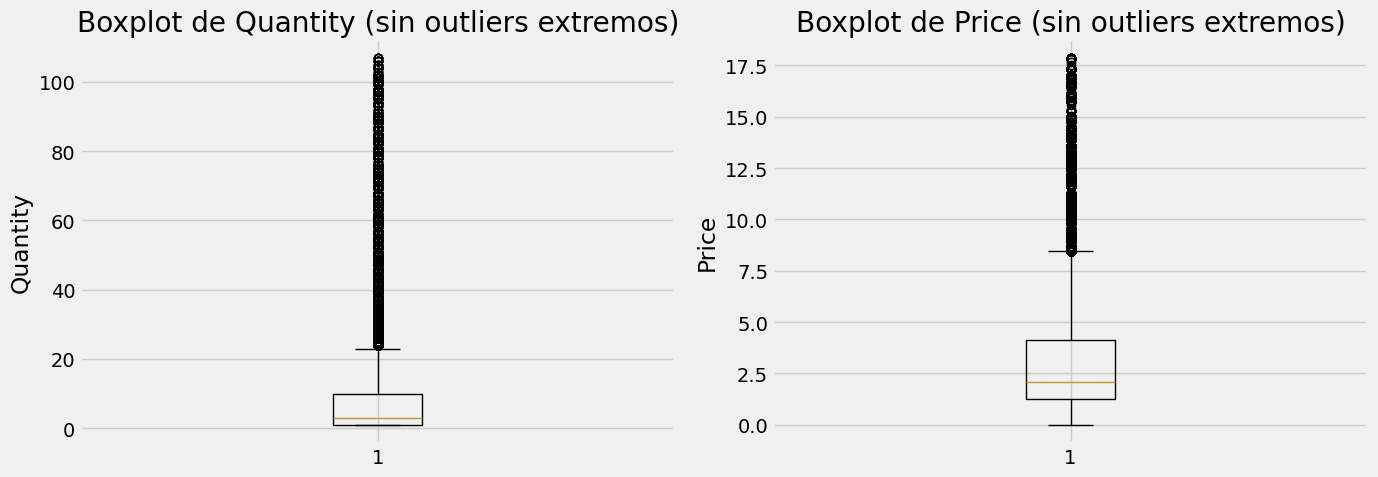

Outliers detectados:
  Quantity > 10,000: 9
  Price > 5,000: 18
  Quantity negativa: 0
  Price negativo o cero: 2621


In [16]:
# Visualización con manejo de outliers

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de Quantity (filtrando valores extremos)
qty_filtered = df[(df['Quantity'] > 0) & (df['Quantity'] < df['Quantity'].quantile(0.99))]['Quantity']
axes[0].boxplot(qty_filtered)
axes[0].set_title('Boxplot de Quantity (sin outliers extremos)')
axes[0].set_ylabel('Quantity')

# Boxplot de Price (filtrando valores extremos)
price_filtered = df[(df['Price'] > 0) & (df['Price'] < df['Price'].quantile(0.99))]['Price']
axes[1].boxplot(price_filtered)
axes[1].set_title('Boxplot de Price (sin outliers extremos)')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

# Estadísticas de outliers
print("Outliers detectados:")
print(f"  Quantity > 10,000: {(df['Quantity'] > 10000).sum()}")
print(f"  Price > 5,000: {(df['Price'] > 5000).sum()}")
print(f"  Quantity negativa: {(df['Quantity'] < 0).sum()}")
print(f"  Price negativo o cero: {(df['Price'] <= 0).sum()}")

# 5. Agrupación por cliente (Customer ID)

In [17]:
# Filtrar clientes válidos (con Customer ID no nulo)
df_valid = df[df['Customer ID'].notna()].copy()

# Agrupar por cliente
clientes = agrupar_clientes(df_valid)

# Mostrar resumen
print(f"Total de clientes: {len(clientes):,}")
print("\nTop 10 clientes por Revenue:")
print(clientes.nlargest(10, 'Revenue_Total')[['Revenue_Total', 'Num_Compras', 'Ticket_Medio', 'País']])

print("\nEstadísticas descriptivas de clientes:")
clientes[['Revenue_Total', 'Num_Compras', 'Ticket_Medio']].describe()

Total de clientes: 5,874

Top 10 clientes por Revenue:
             Revenue_Total  Num_Compras  Ticket_Medio            País
Customer ID                                                          
18102.0          580987.04          145       4006.81  United Kingdom
14646.0          528602.52          152       3477.65     Netherlands
14156.0          313437.62          156       2009.22            EIRE
14911.0          291420.81          398        732.21            EIRE
17450.0          244784.25           51       4799.69  United Kingdom
13694.0          195640.69          143       1368.12  United Kingdom
17511.0          172132.87           60       2868.88  United Kingdom
16446.0          168472.50            2      84236.25  United Kingdom
16684.0          147142.77           55       2675.32  United Kingdom
12415.0          144458.37           28       5159.23       Australia

Estadísticas descriptivas de clientes:


,Revenue_Total,Num_Compras,Ticket_Medio
count,5874.000000,5874.000000,5874.000000
mean,2956.230281,6.291284,384.980858
std,14445.696643,13.019956,1214.695495
min,0.000000,1.000000,0.000000
25%,341.980000,1.000000,176.567500
50%,866.355000,3.000000,279.070000
75%,2248.305000,7.000000,414.900000
max,580987.040000,398.000000,84236.250000


## 6. Modelo: probabilidad de recompra

Modelo supervisado para estimar la probabilidad de que un cliente **vuelva a comprar** después de una fecha de corte.

Estrategia:
- Definimos una **fecha de corte** (`cutoff_date`).
- Con los datos **antes** de esa fecha construimos variables por cliente (RFM simplificado: recencia, frecuencia, gasto total, ticket medio, país, etc.).
- Con los datos **después** de la fecha etiquetamos si el cliente **recompró (1)** o **no recompró (0)**.
- Entrenamos una **regresión logística** para predecir esa probabilidad de recompra.

In [18]:
# Definir fecha de corte basada en el rango real de datos
min_date = df_valid['InvoiceDate'].min()
max_date = df_valid['InvoiceDate'].max()
print(f"Rango de fechas en datos: {min_date} a {max_date}")

# Fecha de corte: 70% del rango de tiempo (para asegurar ambas clases)
total_seconds = (max_date - min_date).total_seconds()
fecha_corte = min_date + pd.to_timedelta(total_seconds * 0.7, unit='s')

print(f"Fecha de corte (70% del rango): {fecha_corte}")

# Verificar que tenemos datos después de la fecha de corte
clientes_despues = df_valid[df_valid.InvoiceDate > fecha_corte]['Customer ID'].nunique()
print(f"Clientes que compraron después de la fecha de corte: {clientes_despues}")

Rango de fechas en datos: 2009-12-01 07:45:00 a 2011-12-09 12:50:00
Fecha de corte (70% del rango): 2011-05-02 01:42:30
Clientes que compraron después de la fecha de corte: 3706


#### Agrupando clientes por Customer ID y fecha de corte

In [19]:
df_modelo=df_valid[df_valid['InvoiceDate'] <= fecha_corte].copy()

# Agrupar por cliente
clientes_modelo = agrupar_clientes(df_modelo)

# Mostrar resumen
print(f"Total de clientes: {len(clientes_modelo):,}")
print("\nTop 10 clientes por Revenue:")
print(clientes_modelo.nlargest(10, 'Revenue_Total')[['Revenue_Total', 'Num_Compras', 'Ticket_Medio', 'País']])

print("\nEstadísticas descriptivas de clientes:")
clientes_modelo[['Revenue_Total', 'Num_Compras', 'Ticket_Medio']].describe()

Total de clientes: 4,819

Top 10 clientes por Revenue:
             Revenue_Total  Num_Compras  Ticket_Medio            País
Customer ID                                                          
18102.0          367806.11           94       3912.83  United Kingdom
14646.0          330701.48           95       3481.07     Netherlands
14156.0          234707.59          117       2006.05            EIRE
14911.0          177072.74          243        728.69            EIRE
13694.0          152408.74          112       1360.79  United Kingdom
17511.0          109607.73           41       2673.36  United Kingdom
16684.0           99138.63           37       2679.42  United Kingdom
15061.0           98929.44          105        942.19  United Kingdom
17450.0           88128.04           15       5875.20  United Kingdom
15311.0           78073.63          154        506.97  United Kingdom

Estadísticas descriptivas de clientes:


,Revenue_Total,Num_Compras,Ticket_Medio
count,4819.000000,4819.000000,4819.000000
mean,2310.679281,5.042955,372.735412
std,10106.546474,9.644771,520.580132
min,0.000000,1.000000,0.000000
25%,310.145000,1.000000,176.310000
50%,731.200000,3.000000,280.910000
75%,1898.890000,6.000000,416.700000
max,367806.110000,243.000000,14844.770000


In [20]:
# Cojo de la lista de clientes que compraron después de la fecha de corte.
pseudo_recompra=df_valid[df_valid.InvoiceDate > fecha_corte]['Customer ID'].unique()
# Hago una segregación de los clientes del modelo que están dentro de la lista de quienes compraron después.
clientes_modelo['Recompró']=np.where(clientes_modelo.index.isin(pseudo_recompra), 1, 0)
print("Fecha de corte:", fecha_corte)
clientes_modelo.head()

Fecha de corte: 2011-05-02 01:42:30


,Revenue_Total,Num_Compras,Primera_Compra,Ultima_Compra,País,Ticket_Medio,Recompró
Customer ID,,,,,,,
12346.0,77556.46,12,2009-12-14 08:34:00,2011-01-18 10:01:00,United Kingdom,6463.04,0
12347.0,2434.96,4,2010-10-31 14:20:00,2011-04-07 10:43:00,Iceland,608.74,1
12348.0,1709.40,4,2010-09-27 14:59:00,2011-04-05 10:47:00,Finland,427.35,1
12349.0,2671.14,3,2010-04-29 13:20:00,2010-10-28 08:23:00,Italy,890.38,1
12350.0,334.40,1,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway,334.40,0


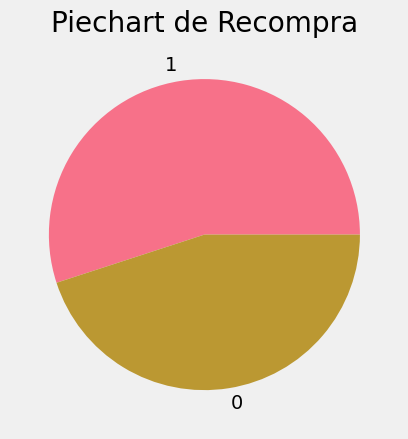

In [21]:
clientes_modelo.Recompró.value_counts().plot(kind='pie',rot=0)
plt.title('Piechart de Recompra')
plt.show()

### Creando el modelo 


In [22]:
# Excluyendo inicialmente País para tratar atributos numéricos
modelo_num=clientes_modelo.drop(columns=["País"])
# Convertiendo a segundos los atributos de fechas 
modelo_num=modelo_num.assign(
    Primera_Compra=modelo_num.Primera_Compra.astype('int64')//10**9, 
    Ultima_Compra=modelo_num.Ultima_Compra.astype('int64')//10**9,    
)
# Tranformando entre 0 y 1
modelo_num=modelo_num.assign(
    Revenue_Total=modelo_num.Revenue_Total.apply(lambda x: escalador_minmax(modelo_num.Revenue_Total,x)),
    Primera_Compra=modelo_num.Primera_Compra.apply(lambda x: escalador_minmax(modelo_num.Primera_Compra,x)),
    Ultima_Compra=modelo_num.Ultima_Compra.apply(lambda x: escalador_minmax(modelo_num.Ultima_Compra,x)),
    Ticket_Medio=modelo_num.Ticket_Medio.apply(lambda x: escalador_minmax(modelo_num.Ticket_Medio,x))
)
#Dummy de los paises
dummies_pais = pd.get_dummies(clientes_modelo["País"],drop_first=True,dtype=int)
#Modelo final
modelo=pd.concat([modelo_num,dummies_pais],axis=1)


### Matriz de correlación

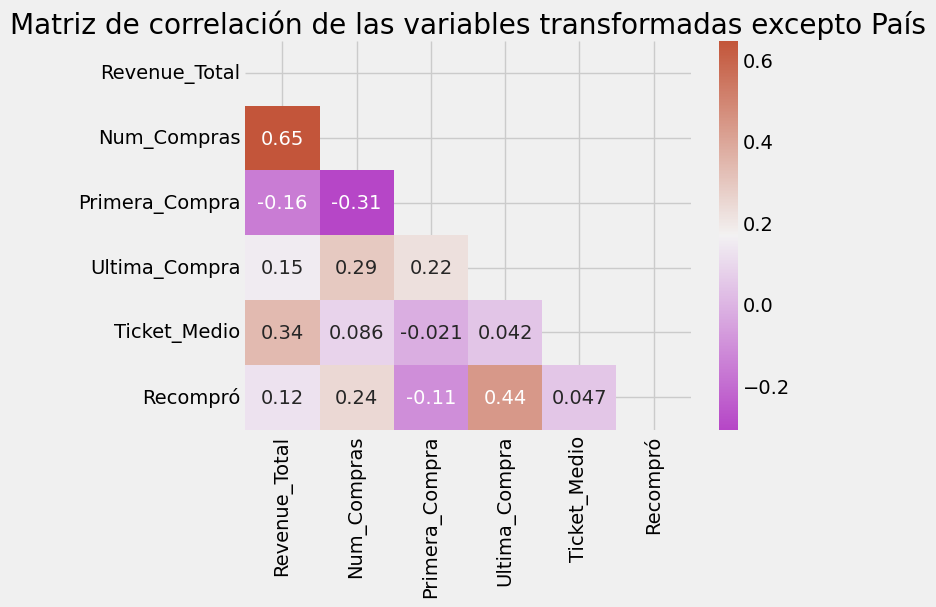

In [23]:
corr =modelo_num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(300, 20, as_cmap=True)
sns.heatmap(corr, annot=True, mask = mask, cmap=cmap)
plt.title('Matriz de correlación de las variables transformadas excepto País')
plt.savefig('imagenes/correlacion.png',dpi=300,bbox_inches='tight')
plt.show()

In [24]:
modelo.sample(5)

,Revenue_Total,Num_Compras,Primera_Compra,Ultima_Compra,Ticket_Medio,Recompró,Austria,Bahrain,Belgium,Brazil,...,Saudi Arabia,Singapore,Spain,Sweden,Switzerland,Thailand,USA,United Arab Emirates,United Kingdom,West Indies
Customer ID,,,,,,,,,,,,,,,,,,,,,
13080.0,0.000605,3,0.250314,0.653177,0.005000,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
12786.0,0.001981,1,0.250247,0.250078,0.049075,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14189.0,0.007198,7,0.678101,0.980718,0.025478,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
15352.0,0.000302,1,0.368330,0.368167,0.007487,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
18109.0,0.009255,21,0.411017,0.962827,0.010920,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


### Rompiendo los datos

In [25]:
from sklearn.model_selection import train_test_split,KFold
main_kfold = KFold(10, shuffle=True, random_state=49)
data_train , data_test = train_test_split(modelo,test_size=0.80,random_state=141) 
#NOTA: omito `stratify=modelo['Recompró']` para no establecer ratios similares al modelo incial en cada partición.

##### Data training

In [26]:
train_x=data_train.drop(columns="Recompró")
train_y=data_train["Recompró"]

#### Data test

In [27]:
test_x=data_test.drop(columns="Recompró")
test_y=data_test["Recompró"]

### 1.Regresíon Logística (Logit)

In [28]:
%%time
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler 
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# VALIDACIÓN CRÍTICA: Verificar que hay ambas clases en train_y
print("=== Validación de datos ===")
print(f"Classes in train_y: {train_y.unique()}")
print(f"Value counts:\n{train_y.value_counts()}")

if len(train_y.unique()) < 2:
    raise ValueError(f"ERROR: train_y solo contiene la clase {train_y.unique()[0]}. "
                     f"Ajusta la fecha de corte para incluir ambas clases (0 y 1).")

# --- Optuna: búsqueda de hiperparámetros ---
def objective(trial):
    C       = trial.suggest_float('C', 1e-4, 100, log=True)
    solver  = trial.suggest_categorical('solver', ['lbfgs', 'saga'])  # Removed liblinear
    penalty = trial.suggest_categorical('penalty', ['l2', None])
    
    # lbfgs doesn't support None penalty (no regularization)
    if solver == 'lbfgs' and penalty is None:
        penalty = 'l2'
    
    pipe = Pipeline([
        ('scale', RobustScaler()),
        ('lr', LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000))
    ])
    
    try:
        scores = cross_val_score(pipe, train_x, train_y,
                                 cv=main_kfold, scoring='roc_auc', n_jobs=-1)
        return scores.mean()
    except Exception as e:
        # If a fold fails (e.g., only one class), return poor score
        return 0.0

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, catch=(Exception,))  # Reduced trials, catch all errors

print("\n=== Mejores hiperparámetros ===")
print(study.best_params)
print(f"Mejor ROC-AUC (cv): {study.best_value:.4f}")

# --- Entrenar modelo final con mejores parámetros ---
best = study.best_params
penalty = best.get('penalty', 'l2') if best.get('penalty') is not None else 'l2'

lr_pipe = Pipeline([
    ('scale', RobustScaler()),
    ('lr', LogisticRegression(C=best['C'], penalty=penalty, 
                              solver=best['solver'], max_iter=1000))
])

scoring = {'accuracy': 'accuracy', 'roc_auc': 'roc_auc', 'f1': 'f1'}
lr_scores = cross_validate(lr_pipe, train_x, train_y,
                           scoring=scoring, cv=main_kfold,
                           return_train_score=True, return_estimator=True, n_jobs=-1,
                           error_score='raise')  # Show errors during cv
lr_pipe.fit(train_x, train_y)

# --- Probabilidades de recompra ---
prob_recompra = lr_pipe.predict_proba(test_x)[:, 1]

# --- Resultados ---
print("\n=== Validación cruzada (train/val) ===")
for metric in scoring:
    train_m = lr_scores[f'train_{metric}'].mean()
    val_m   = lr_scores[f'test_{metric}'].mean()
    print(f"  {metric:10s}  train: {train_m:.4f}  |  val: {val_m:.4f}")

print("\n=== Evaluación en test ===")
print(classification_report(test_y, lr_pipe.predict(test_x), target_names=['No recompra', 'Recompra']))
print(f"ROC-AUC en test: {roc_auc_score(test_y, prob_recompra):.4f}")

# --- Muestra de probabilidades predichas ---
test_result = test_x.copy()
test_result['P_Recompra'] = prob_recompra
test_result['Real'] = test_y.values
print("\nMuestra de probabilidades predichas:")
print(test_result[['P_Recompra', 'Real']].sample(10))

=== Validación de datos ===
Classes in train_y: [1 0]
Value counts:
Recompró
1    520
0    443
Name: count, dtype: int64

=== Mejores hiperparámetros ===
{'C': 0.0031859492537648732, 'solver': 'saga', 'penalty': 'l2'}
Mejor ROC-AUC (cv): 0.7742

=== Validación cruzada (train/val) ===
  accuracy    train: 0.7009  |  val: 0.6917
  roc_auc     train: 0.7730  |  val: 0.7742
  f1          train: 0.7293  |  val: 0.7209

=== Evaluación en test ===
              precision    recall  f1-score   support

 No recompra       0.68      0.68      0.68      1725
    Recompra       0.74      0.75      0.74      2131

    accuracy                           0.72      3856
   macro avg       0.71      0.71      0.71      3856
weighted avg       0.72      0.72      0.72      3856

ROC-AUC en test: 0.7987

Muestra de probabilidades predichas:
             P_Recompra  Real
Customer ID                  
15351.0        0.542630     1
14155.0        0.505898     0
14284.0        0.374182     1
12839.0        0

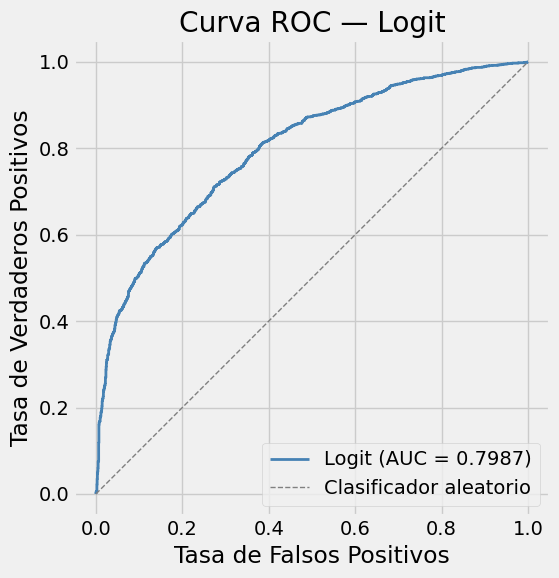

In [29]:
curva_roc("Logit", test_y, prob_recompra,"steelblue")

#### Resultados

Top 15 variables más relevantes:
      Variable  Coeficiente      Abs
 Ultima_Compra     0.257380 0.257380
   Num_Compras     0.218696 0.218696
 Revenue_Total     0.156760 0.156760
  Ticket_Medio    -0.038624 0.038624
Primera_Compra    -0.038126 0.038126
       Germany     0.009201 0.009201
           USA    -0.003455 0.003455
        Greece    -0.003412 0.003412
        Sweden    -0.002669 0.002669
United Kingdom     0.002458 0.002458
         Spain     0.001977 0.001977
      Portugal    -0.001815 0.001815
        Canada    -0.001559 0.001559
        Brazil    -0.001544 0.001544
   Netherlands     0.001536 0.001536


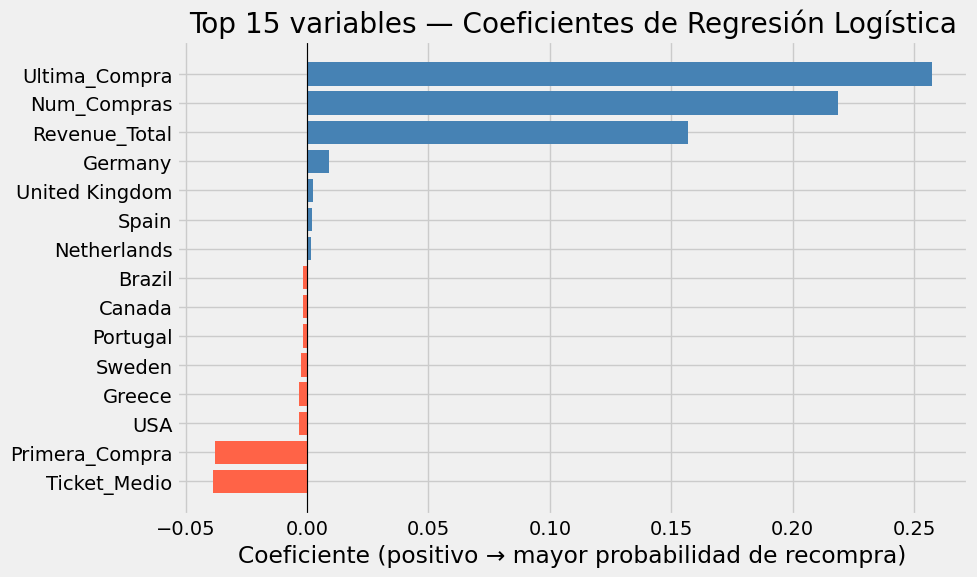

In [30]:
# Importancia de variables: coeficientes de la regresión logística
coef = lr_pipe.named_steps['lr'].coef_[0]
features = train_x.columns

importancia = (pd.DataFrame({'Variable': features, 'Coeficiente': coef})
               .assign(Abs=lambda x: x['Coeficiente'].abs())
               .sort_values('Abs', ascending=False)
               .reset_index(drop=True))

print("Top 15 variables más relevantes:")
print(importancia.head(15).to_string(index=False))

# Visualización
top_n = 15
top = importancia.head(top_n).sort_values('Coeficiente')

colors = ['tomato' if c < 0 else 'steelblue' for c in top['Coeficiente']]
plt.figure(figsize=(10, 6))
plt.barh(top['Variable'], top['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Top {top_n} variables — Coeficientes de Regresión Logística')
plt.xlabel('Coeficiente (positivo → mayor probabilidad de recompra)')
plt.tight_layout()
plt.savefig('imagenes/Logit_var.png',dpi=300,bbox_inches='tight')
plt.show()

### 2.XGBoost

In [31]:
%%time
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# VALIDACIÓN CRÍTICA: Verificar que hay ambas clases en train_y
print("=== Validación de datos ===")
print(f"Classes in train_y: {train_y.unique()}")
print(f"Value counts:\n{train_y.value_counts()}")

if len(train_y.unique()) < 2:
    raise ValueError(f"ERROR: train_y solo contiene la clase {train_y.unique()[0]}. "
                     f"Ajusta la fecha de corte para incluir ambas clases (0 y 1).")

# --- Optuna: búsqueda de hiperparámetros ---
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'random_state': 49,
        'eval_metric': 'logloss'
    }
    
    pipe = Pipeline([
        ('scale', RobustScaler()),
        ('xgb', XGBClassifier(**params, use_label_encoder=False))
    ])
    
    try:
        scores = cross_val_score(pipe, train_x, train_y,
                                 cv=main_kfold, scoring='roc_auc', n_jobs=-1)
        return scores.mean()
    except Exception as e:
        return 0.0

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=30, catch=(Exception,))

print("\n=== Mejores hiperparámetros ===")
print(study_xgb.best_params)
print(f"Mejor ROC-AUC (cv): {study_xgb.best_value:.4f}")

# --- Entrenar modelo final con mejores parámetros ---
best_xgb = study_xgb.best_params
xgb_pipe = Pipeline([
    ('scale', RobustScaler()),
    ('xgb', XGBClassifier(**best_xgb, random_state=49, use_label_encoder=False, eval_metric='logloss'))
])

scoring = {'accuracy': 'accuracy', 'roc_auc': 'roc_auc', 'f1': 'f1'}
xgb_scores = cross_validate(xgb_pipe, train_x, train_y,
                           scoring=scoring, cv=main_kfold,
                           return_train_score=True, return_estimator=True, n_jobs=-1,
                           error_score='raise')
xgb_pipe.fit(train_x, train_y)

# --- Probabilidades de recompra ---
prob_recompra_xgb = xgb_pipe.predict_proba(test_x)[:, 1]

# --- Resultados ---
print("\n=== Validación cruzada (train/val) ===")
for metric in scoring:
    train_m = xgb_scores[f'train_{metric}'].mean()
    val_m   = xgb_scores[f'test_{metric}'].mean()
    print(f"  {metric:10s}  train: {train_m:.4f}  |  val: {val_m:.4f}")

print("\n=== Evaluación en test ===")
print(classification_report(test_y, xgb_pipe.predict(test_x), target_names=['No recompra', 'Recompra']))
print(f"ROC-AUC en test: {roc_auc_score(test_y, prob_recompra_xgb):.4f}")

# --- Muestra de probabilidades predichas ---
test_result_xgb = test_x.copy()
test_result_xgb['P_Recompra'] = prob_recompra_xgb
test_result_xgb['Real'] = test_y.values
print("\nMuestra de probabilidades predichas:")
print(test_result_xgb[['P_Recompra', 'Real']].sample(10))

=== Validación de datos ===
Classes in train_y: [1 0]
Value counts:
Recompró
1    520
0    443
Name: count, dtype: int64

=== Mejores hiperparámetros ===
{'n_estimators': 363, 'max_depth': 9, 'learning_rate': 0.010373785848091666, 'subsample': 0.8135854028069408, 'colsample_bytree': 0.9329064563512064, 'gamma': 4.112725544436252, 'min_child_weight': 5, 'reg_alpha': 1.9277322241140312e-07, 'reg_lambda': 1.5196985246227803}
Mejor ROC-AUC (cv): 0.7922

=== Validación cruzada (train/val) ===
  accuracy    train: 0.7584  |  val: 0.7196
  roc_auc     train: 0.8353  |  val: 0.7922
  f1          train: 0.7670  |  val: 0.7247

=== Evaluación en test ===
              precision    recall  f1-score   support

 No recompra       0.66      0.73      0.70      1725
    Recompra       0.76      0.70      0.73      2131

    accuracy                           0.71      3856
   macro avg       0.71      0.72      0.71      3856
weighted avg       0.72      0.71      0.71      3856

ROC-AUC en test: 0.8

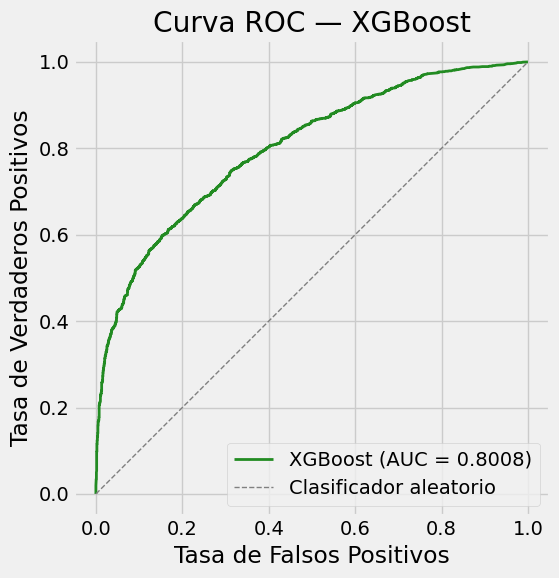

In [32]:
curva_roc("XGBoost", test_y, prob_recompra_xgb,"forestgreen")

#### Resultados

Top 15 variables más relevantes:
      Variable  Importancia
   Num_Compras     0.405461
 Ultima_Compra     0.191716
 Revenue_Total     0.163468
  Ticket_Medio     0.087092
Primera_Compra     0.085266
United Kingdom     0.066997
           RSA     0.000000
         Malta     0.000000
   Netherlands     0.000000
       Nigeria     0.000000
        Norway     0.000000
        Poland     0.000000
      Portugal     0.000000
         Spain     0.000000
  Saudi Arabia     0.000000


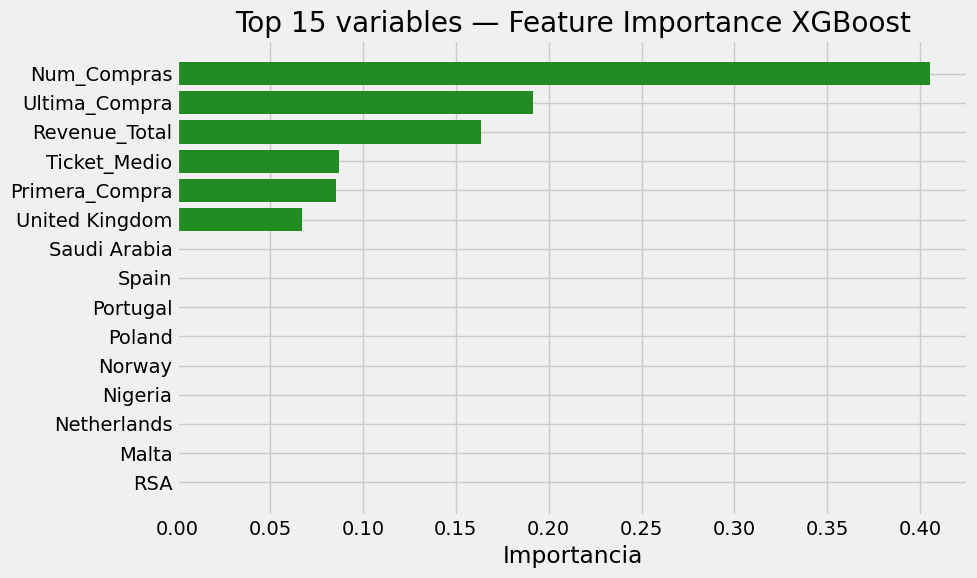

In [33]:
# Importancia de variables: feature importance de XGBoost
importances_xgb = xgb_pipe.named_steps['xgb'].feature_importances_
features = train_x.columns

importancia_xgb = (pd.DataFrame({'Variable': features, 'Importancia': importances_xgb})
                   .sort_values('Importancia', ascending=False)
                   .reset_index(drop=True))

print("Top 15 variables más relevantes:")
print(importancia_xgb.head(15).to_string(index=False))

# Visualización
top_n = 15
top_xgb = importancia_xgb.head(top_n).sort_values('Importancia')

plt.figure(figsize=(10, 6))
plt.barh(top_xgb['Variable'], top_xgb['Importancia'], color='forestgreen')
plt.title(f'Top {top_n} variables — Feature Importance XGBoost')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('imagenes/XGBoost_var.png',dpi=300,bbox_inches='tight')
plt.show()

### 3.LightGBM

In [34]:
%%time
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# VALIDACIÓN CRÍTICA: Verificar que hay ambas clases en train_y
print("=== Validación de datos ===")
print(f"Classes in train_y: {train_y.unique()}")
print(f"Value counts:\n{train_y.value_counts()}")

if len(train_y.unique()) < 2:
    raise ValueError(f"ERROR: train_y solo contiene la clase {train_y.unique()[0]}. "
                     f"Ajusta la fecha de corte para incluir ambas clases (0 y 1).")

# --- Optuna: búsqueda de hiperparámetros ---
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'random_state': 49,
        'verbosity': -1
    }
    
    pipe = Pipeline([
        ('scale', RobustScaler()),
        ('lgbm', LGBMClassifier(**params))
    ])
    
    try:
        scores = cross_val_score(pipe, train_x, train_y,
                                 cv=main_kfold, scoring='roc_auc', n_jobs=-1)
        return scores.mean()
    except Exception as e:
        return 0.0

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=30, catch=(Exception,))

print("\n=== Mejores hiperparámetros ===")
print(study_lgbm.best_params)
print(f"Mejor ROC-AUC (cv): {study_lgbm.best_value:.4f}")

# --- Entrenar modelo final con mejores parámetros ---
best_lgbm = study_lgbm.best_params
lgbm_pipe = Pipeline([
    ('scale', RobustScaler()),
    ('lgbm', LGBMClassifier(**best_lgbm, random_state=49, verbosity=-1))
])

scoring = {'accuracy': 'accuracy', 'roc_auc': 'roc_auc', 'f1': 'f1'}
lgbm_scores = cross_validate(lgbm_pipe, train_x, train_y,
                            scoring=scoring, cv=main_kfold,
                            return_train_score=True, return_estimator=True, n_jobs=-1,
                            error_score='raise')
lgbm_pipe.fit(train_x, train_y)

# --- Probabilidades de recompra ---
prob_recompra_lgbm = lgbm_pipe.predict_proba(test_x)[:, 1]

# --- Resultados ---
print("\n=== Validación cruzada (train/val) ===")
for metric in scoring:
    train_m = lgbm_scores[f'train_{metric}'].mean()
    val_m   = lgbm_scores[f'test_{metric}'].mean()
    print(f"  {metric:10s}  train: {train_m:.4f}  |  val: {val_m:.4f}")

print("\n=== Evaluación en test ===")
print(classification_report(test_y, lgbm_pipe.predict(test_x), target_names=['No recompra', 'Recompra']))
print(f"ROC-AUC en test: {roc_auc_score(test_y, prob_recompra_lgbm):.4f}")

# --- Muestra de probabilidades predichas ---
test_result_lgbm = test_x.copy()
test_result_lgbm['P_Recompra'] = prob_recompra_lgbm
test_result_lgbm['Real'] = test_y.values
print("\nMuestra de probabilidades predichas:")
print(test_result_lgbm[['P_Recompra', 'Real']].sample(10))

=== Validación de datos ===
Classes in train_y: [1 0]
Value counts:
Recompró
1    520
0    443
Name: count, dtype: int64

=== Mejores hiperparámetros ===
{'n_estimators': 220, 'max_depth': 6, 'learning_rate': 0.012479688456111459, 'num_leaves': 79, 'subsample': 0.8708646983535961, 'colsample_bytree': 0.7051726411484727, 'min_child_samples': 79, 'reg_alpha': 6.874211242626578, 'reg_lambda': 0.039454884243439035}
Mejor ROC-AUC (cv): 0.7882

=== Validación cruzada (train/val) ===
  accuracy    train: 0.7392  |  val: 0.7061
  roc_auc     train: 0.8172  |  val: 0.7882
  f1          train: 0.7532  |  val: 0.7209

=== Evaluación en test ===
              precision    recall  f1-score   support

 No recompra       0.68      0.71      0.69      1725
    Recompra       0.76      0.72      0.74      2131

    accuracy                           0.72      3856
   macro avg       0.72      0.72      0.72      3856
weighted avg       0.72      0.72      0.72      3856

ROC-AUC en test: 0.7963

Muestr

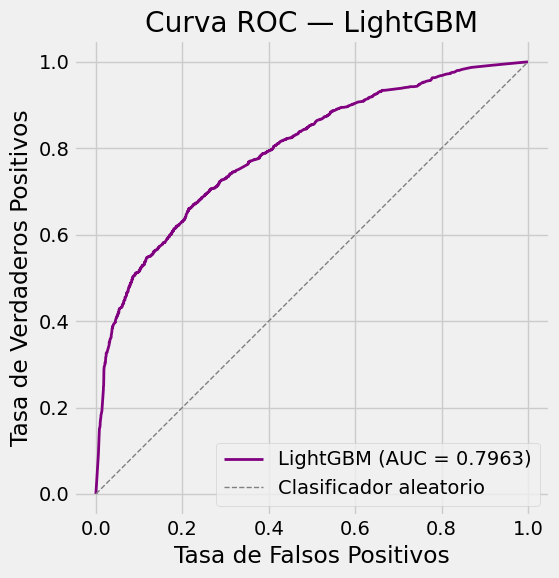

In [35]:
curva_roc("LightGBM", test_y, prob_recompra_lgbm,color="purple")

#### Resultados

Top 15 variables más relevantes:
      Variable  Importancia
 Ultima_Compra          382
  Ticket_Medio          273
   Num_Compras          175
 Revenue_Total          169
Primera_Compra           78
  Saudi Arabia            0
         Malta            0
   Netherlands            0
       Nigeria            0
        Norway            0
        Poland            0
      Portugal            0
           RSA            0
         Spain            0
     Singapore            0


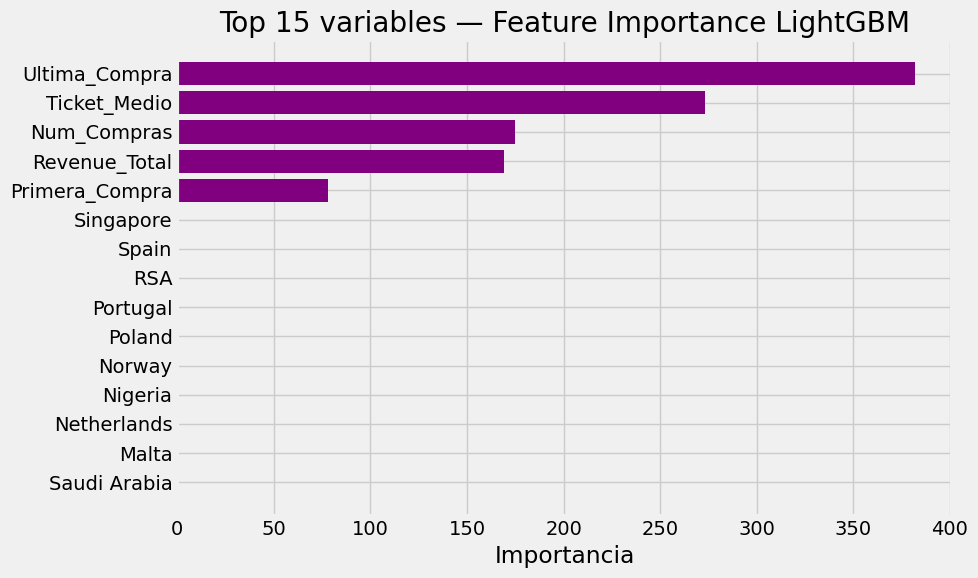

In [36]:
# Aquí la gráfica
# Importancia de variables: feature importance de LightGBM
importances_lgbm = lgbm_pipe.named_steps['lgbm'].feature_importances_
features = train_x.columns

importancia_lgbm = (pd.DataFrame({'Variable': features, 'Importancia': importances_lgbm})
                    .sort_values('Importancia', ascending=False)
                    .reset_index(drop=True))

print("Top 15 variables más relevantes:")
print(importancia_lgbm.head(15).to_string(index=False))

# Visualización
top_n = 15
top_lgbm = importancia_lgbm.head(top_n).sort_values('Importancia')

plt.figure(figsize=(10, 6))
plt.barh(top_lgbm['Variable'], top_lgbm['Importancia'], color='purple')
plt.title(f'Top {top_n} variables — Feature Importance LightGBM')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('imagenes/LightGBM_var.png',dpi=300,bbox_inches='tight')
plt.show()